In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import torch
from matplotlib.colors import to_hex
from scipy.optimize import linear_sum_assignment

sys.path.append('../..')
import sherlock as slk

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_RUNS      = 5
NUM_EPOCHS  = 200
VALIDATE_EVERY = 50
BATCH_SIZE  = 4096
LATENT_DIM  = 16
PATIENCE    = 20
RESULTS_DIR = "results/benchmarking"
N_CLUSTERS  = 10

# Metrics tracked for scoring and box plots
METRIC_COLS = [
    'cf_ate_pearson_r',
    'cluster_f1',
    'cluster_ari',
    'cluster_ami',
    'cluster_silhouette',
    'cluster_linear_probe',
    'cluster_knn_purity',
]

# (model_key, display_name, method-specific kwargs)
# sherlock (vae) kwargs mirror the tuned hyperparameters in "demo copy.ipynb"
# (cov_lambda / H_lambda / gate_row_repulsion_lambda disabled, ce_lambda raised to 20)
METHODS = [
    ("vae",           "sherlock",      {
        "l0_lambda": 4,
        "ce_lambda": 20.,
        "n_epochs_l0_warmup": 200,
    },  500),
    ("svae",          "sVAE",          {"sparse_mask_penalty": 10.0},  NUM_EPOCHS),
    ("cvae",          "cVAE",          {},  NUM_EPOCHS),
    ("contrastivevi", "contrastiveVI", {},  NUM_EPOCHS),
    ("scgen",         "scgen",         {},  NUM_EPOCHS),
]

os.makedirs(f"{RESULTS_DIR}/models",   exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/figures",  exist_ok=True)

print(f"Device: {DEVICE}  Results: {RESULTS_DIR}")

Device: cuda  Results: results/benchmarking


## Data loading and ground-truth ATE

In [4]:
data = slk.datasets.replogle()

slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
treat_effect_adata = data.uns['treat_effect']
print(f"Cells: {data.n_obs}  Genes: {data.n_vars}  Perturbations: {data.obs['pert'].nunique()}")

100%|██████████| 681/681 [00:09<00:00, 73.73it/s]

Cells: 118641  Genes: 1185  Perturbations: 682


## Pathway annotations for clustering evaluation

In [5]:
pathways = data.uns['pathways']

all_genes_filtered = [
    gene
    for genes in pathways.values()
    for gene in genes
    if gene != 'LSM5'
]

gene_to_pathway = {
    gene: pathway
    for pathway, genes in pathways.items()
    for gene in genes
    if gene != 'LSM5'
}
pathway_df_indexed = pd.DataFrame.from_dict(
    gene_to_pathway, orient='index', columns=['pathway']
)
pathway_df_indexed.index.name = 'gene'

print(f"Pathway genes: {len(all_genes_filtered)}  Pathways: {len(pathways)}")

Pathway genes: 335  Pathways: 8


## Benchmark loop

Each method is trained `N_RUNS` times independently. The best-scoring run
per method is saved to `results/models/`. Metrics are computed after training
using the proper counterfactual ATE protocol; the clustering cut is chosen
automatically via the elbow method.

In [6]:
records         = []
best_run_out    = {}   # method → out dict of best single run
best_run_model  = {}   # method → model of best single run
best_run_score  = {}   # method → avg metric score of best single run

for model_key, display_name, extra_kwargs, EPOCHS, in METHODS:
    print(f"\n{'='*60}\n{display_name}  ({N_RUNS} runs)\n{'='*60}")
    best_run_score[display_name] = -np.inf

    # Each method gets its own folder; individual runs are checkpointed there
    # so a re-executed notebook reloads finished runs instead of retraining.
    model_dir = f"{RESULTS_DIR}/models/{display_name}"
    os.makedirs(model_dir, exist_ok=True)

    for run in range(N_RUNS):
        print(f"\n  -- {display_name} run {run + 1}/{N_RUNS} --")

        run_path = f"{model_dir}/run_{run}.pth"

        if os.path.exists(run_path):
            print(f"    Found checkpoint → {run_path}, loading instead of retraining")
            model = slk.tl.load_results(run_path).to(DEVICE)
            out = {"model": model, "param_store": None}
        else:
            out = slk.tl.run(
                data,
                model=model_key,
                batch_size=BATCH_SIZE,
                num_epochs=EPOCHS,
                device=DEVICE,
                latent_dim=LATENT_DIM,
                patience=PATIENCE,
                validate_every=VALIDATE_EVERY,
                seed=run,
                **extra_kwargs,
            )
            model = out['model']
            slk.tl.save_results(out, run_path)
            print(f"    Saved → {run_path}")

        metrics = slk.tl.evaluate_model(
            model,
            data,
            treat_effect_adata,
            pathway_df_indexed,
            all_genes_filtered,
            n_clusters=N_CLUSTERS,
            device=DEVICE,
            use_rho=False,
        )

        # Track best run for this method
        run_avg = float(metrics['cf_ate_pearson_r'])
        if run_avg > best_run_score[display_name]:
            best_run_score[display_name] = run_avg
            best_run_out[display_name]   = out
            best_run_model[display_name] = model

        metrics['method'] = display_name
        metrics['run']    = run
        records.append(metrics)

        for k, v in metrics.items():
            if k not in ('method', 'run'):
                val_str = f"{v:.4f}" if np.isfinite(float(v)) else "NaN"
                print(f"    {k:30s} = {val_str}")

    # Save best run model for this method
    save_path = f"{model_dir}/best.pth"
    slk.tl.save_results(best_run_out[display_name], save_path)
    print(f"\n  Saved best {display_name} model → {save_path}")

results_df = pd.DataFrame(records)
print("\nDone.")


sherlock  (5 runs)

  -- sherlock run 1/5 --
Training VAE on cuda …


Epochs:   0%|          | 0/500 [00:00<?, ?it/s]

    Saved → results/benchmarking/models/sherlock/run_0.pth
    cf_ate_pearson_r               = 0.5627
    cluster_accuracy               = 0.9493
    cluster_precision              = 0.9361
    cluster_recall                 = 0.9424
    cluster_f1                     = 0.9313
    cluster_ari                    = 0.7572
    cluster_ami                    = 0.8846
    cluster_homogeneity            = 0.9476
    cluster_completeness           = 0.8398
    cluster_v_measure              = 0.8904
    cluster_silhouette             = 0.3998
    cluster_purity                 = 0.9493
    cluster_knn_purity             = 0.9857
    cluster_linear_probe           = 0.9910
    rho_z_pearson_r                = 0.6860

  -- sherlock run 2/5 --
Training VAE on cuda …


Epochs:   0%|          | 0/500 [00:00<?, ?it/s]

    Saved → results/benchmarking/models/sherlock/run_1.pth
    cf_ate_pearson_r               = 0.5625
    cluster_accuracy               = 0.9881
    cluster_precision              = 0.9912
    cluster_recall                 = 0.9888
    cluster_f1                     = 0.9898
    cluster_ari                    = 0.7887
    cluster_ami                    = 0.9115
    cluster_homogeneity            = 0.9765
    cluster_completeness           = 0.8624
    cluster_v_measure              = 0.9159
    cluster_silhouette             = 0.3912
    cluster_purity                 = 0.9881
    cluster_knn_purity             = 0.9863
    cluster_linear_probe           = 0.9910
    rho_z_pearson_r                = 0.6822

  -- sherlock run 3/5 --
Training VAE on cuda …


...

Early stopping at epoch 190 (best loss=116.0893)
    Saved → results/benchmarking/models/scgen/run_2.pth
    cf_ate_pearson_r               = 0.7796
    cluster_accuracy               = 0.8687
    cluster_precision              = 0.8168
    cluster_recall                 = 0.8145
    cluster_f1                     = 0.8077
    cluster_ari                    = 0.8333
    cluster_ami                    = 0.8158
    cluster_homogeneity            = 0.8490
    cluster_completeness           = 0.8033
    cluster_v_measure              = 0.8255
    cluster_silhouette             = 0.2098
    cluster_purity                 = 0.8806
    cluster_knn_purity             = 0.9606
    cluster_linear_probe           = 0.9821
    rho_z_pearson_r                = 1.0000

  -- scgen run 4/5 --


scGEN:   0%|          | 0/200 [00:00<?, ?it/s]

    Saved → results/benchmarking/models/scgen/run_3.pth
    cf_ate_pearson_r               = 0.7896
    cluster_accuracy               = 0.8896
    cluster_precision              = 0.8874
    cluster_recall                 = 0.8359
    cluster_f1                     = 0.8335
    cluster_ari                    = 0.7758
    cluster_ami                    = 0.8209
    cluster_homogeneity            = 0.8574
    cluster_completeness           = 0.8047
    cluster_v_measure              = 0.8302
    cluster_silhouette             = 0.2379
    cluster_purity                 = 0.8896
    cluster_knn_purity             = 0.9606
    cluster_linear_probe           = 0.9851
    rho_z_pearson_r                = 1.0000

  -- scgen run 5/5 --


scGEN:   0%|          | 0/200 [00:00<?, ?it/s]

    Saved → results/benchmarking/models/scgen/run_4.pth
    cf_ate_pearson_r               = 0.7839
    cluster_accuracy               = 0.8716
    cluster_precision              = 0.8612
    cluster_recall                 = 0.7915
    cluster_f1                     = 0.7934
    cluster_ari                    = 0.7507
    cluster_ami                    = 0.8032
    cluster_homogeneity            = 0.8422
    cluster_completeness           = 0.7866
    cluster_v_measure              = 0.8134
    cluster_silhouette             = 0.2016
    cluster_purity                 = 0.8716
    cluster_knn_purity             = 0.9504
    cluster_linear_probe           = 0.9851
    rho_z_pearson_r                = 1.0000

  Saved best scgen model → results/benchmarking/models/scgen/best.pth

Done.


## Results summary

In [7]:
summary = (
    results_df
    .groupby('method')[METRIC_COLS]
    .agg(['mean', 'std'])
    .round(4)
)
# Preserve METHODS order
method_order = [m[1] for m in METHODS]
summary = summary.reindex([m for m in method_order if m in summary.index])
print(summary.to_string())

              cf_ate_pearson_r         cluster_f1         cluster_ari         cluster_ami         cluster_silhouette         cluster_linear_probe         cluster_knn_purity        
                          mean     std       mean     std        mean     std        mean     std               mean     std                 mean     std               mean     std
method                                                                                                                                                                              
sherlock                0.5754  0.0225     0.9766  0.0253      0.8314  0.0734      0.9154  0.0212             0.3912  0.0062               0.9922  0.0034             0.9821  0.0038
sVAE                    0.2698  0.0071     0.8782  0.1050      0.6987  0.1070      0.7943  0.1002             0.2899  0.0368               0.9893  0.0016             0.9426  0.0200
cVAE                    0.4240  0.0261     0.8076  0.0136      0.6967  0.0434      0.8348  0.04

## Box plots

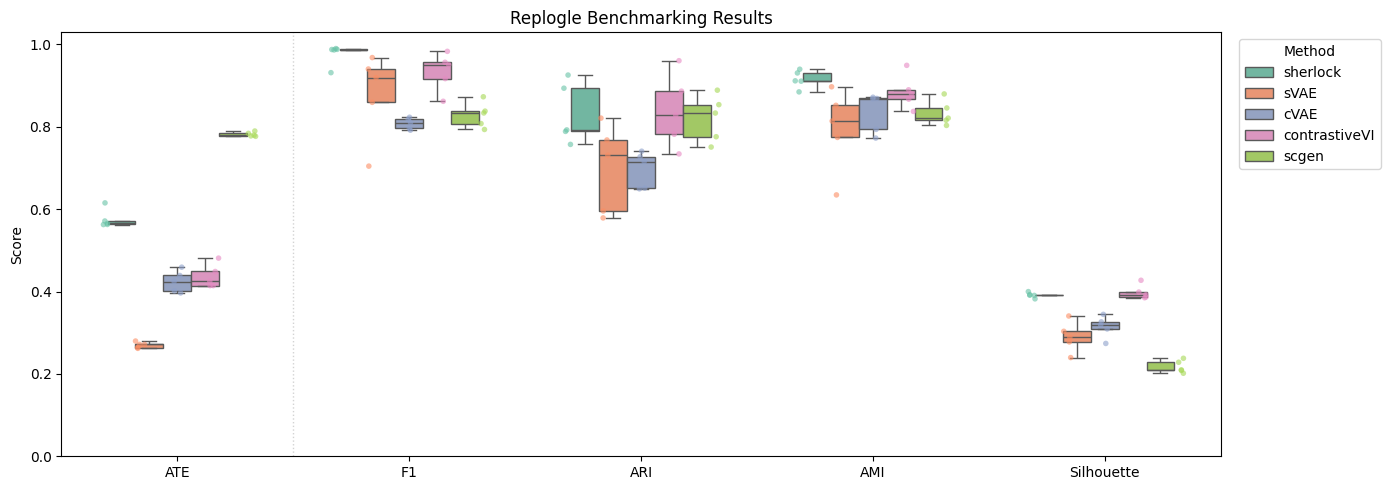

In [8]:
label_map = {
    'cf_ate_pearson_r':   'ATE',
    'cluster_f1':         'F1',
    'cluster_ari':        'ARI',
    'cluster_ami':        'AMI',
    'cluster_silhouette': 'Silhouette',
    # 'cluster_linear_probe': 'Linear\nProbe',
    # 'cluster_knn_purity': 'kNN\nPurity',
}

METRIC_COLS_PLOT = [
    m for m in METRIC_COLS
    if m not in ['cluster_linear_probe', 'cluster_knn_purity']
]

method_order = [m[1] for m in METHODS]

df_melted = results_df.melt(
    id_vars='method', value_vars=METRIC_COLS_PLOT, var_name='metric', value_name='value'
)
df_melted['metric_label'] = pd.Categorical(
    df_melted['metric'].map(label_map),
    categories=[label_map[m] for m in METRIC_COLS_PLOT],
    ordered=True,
)
df_melted['method'] = pd.Categorical(
    df_melted['method'], categories=method_order, ordered=True
)
df_melted['value'] = df_melted['value'].clip(lower=0)

fig, ax = plt.subplots(figsize=(14, 5))

sns.boxplot(
    data=df_melted,
    x='metric_label',
    y='value',
    hue='method',
    palette='Set2',
    width=0.6,
    showfliers=False,
    ax=ax,
)

sns.stripplot(
    data=df_melted,
    x='metric_label',
    y='value',
    hue='method',
    palette='Set2',
    dodge=True,
    size=4,
    alpha=0.6,
    legend=False,
    ax=ax,
)

ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_title('Replogle Benchmarking Results')
ax.legend(title='Method', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(bottom=0)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# Separator between ATE and clustering metrics
ax.axvline(0.5, color='lightgray', linewidth=1.0, linestyle=':')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/benchmark_boxplot.svg', bbox_inches='tight')
plt.show()

## Per-method best models — latent space UMAPs

For each method, re-eval the best run, compute UMAP on non-NTC cells, cluster the
pathway-gene subset of z_corr (maxclust), align predicted clusters to true pathways
via Hungarian matching, and save the figure.


Generating figure for best sherlock model


/var/tmp/ipykernel_3799799/4013088432.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/sherlock_best_umap.svg


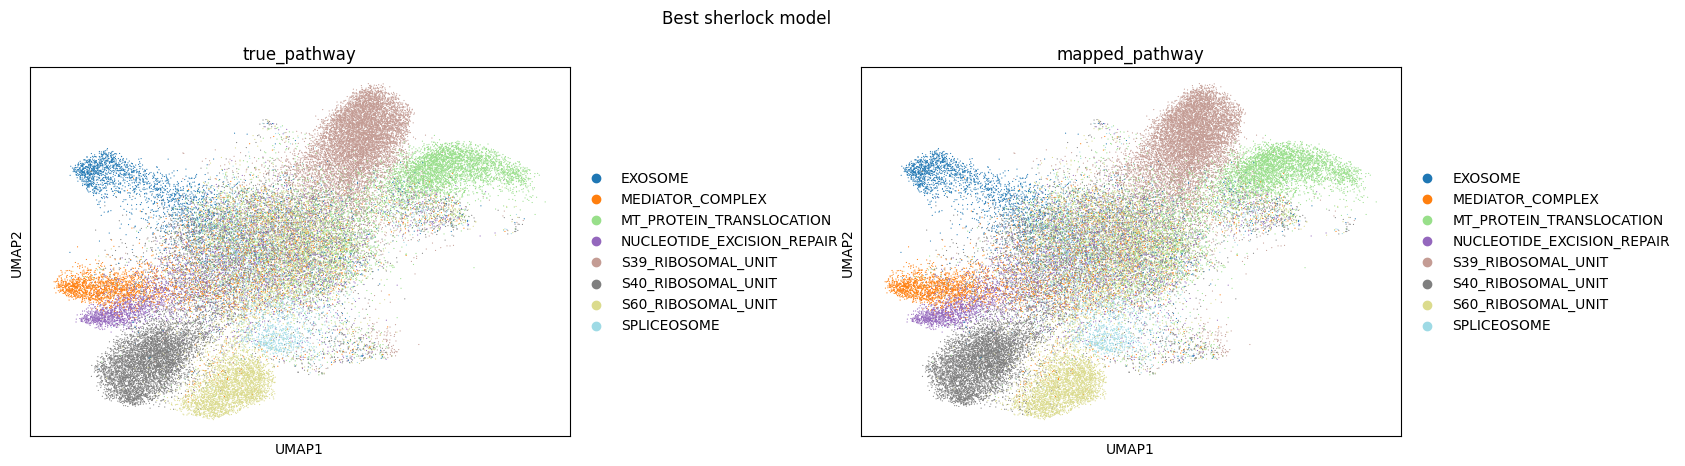


Generating figure for best sVAE model


/var/tmp/ipykernel_3799799/4013088432.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/sVAE_best_umap.svg


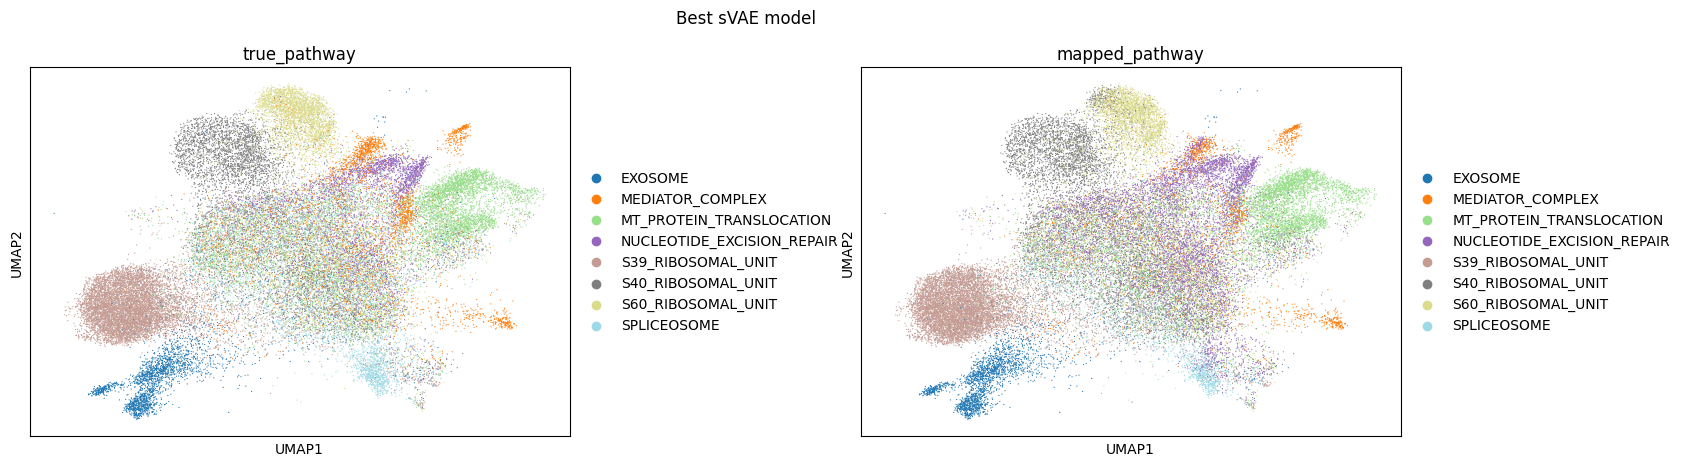


Generating figure for best cVAE model


/var/tmp/ipykernel_3799799/4013088432.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/cVAE_best_umap.svg


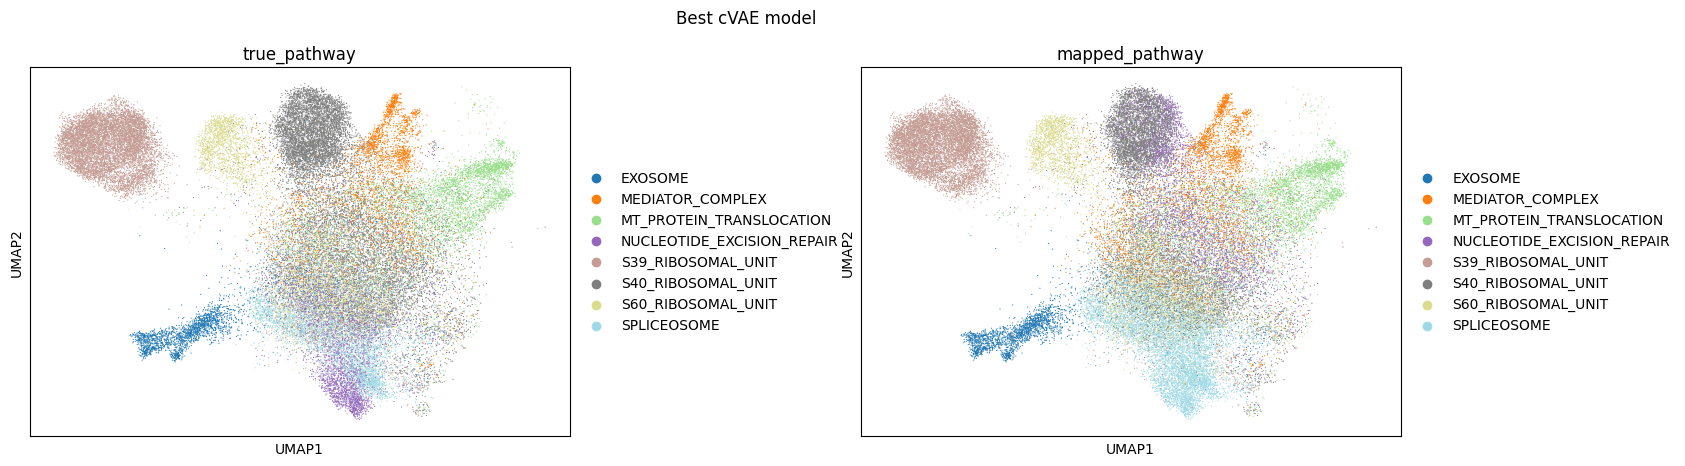


Generating figure for best contrastiveVI model


/var/tmp/ipykernel_3799799/4013088432.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/contrastiveVI_best_umap.svg


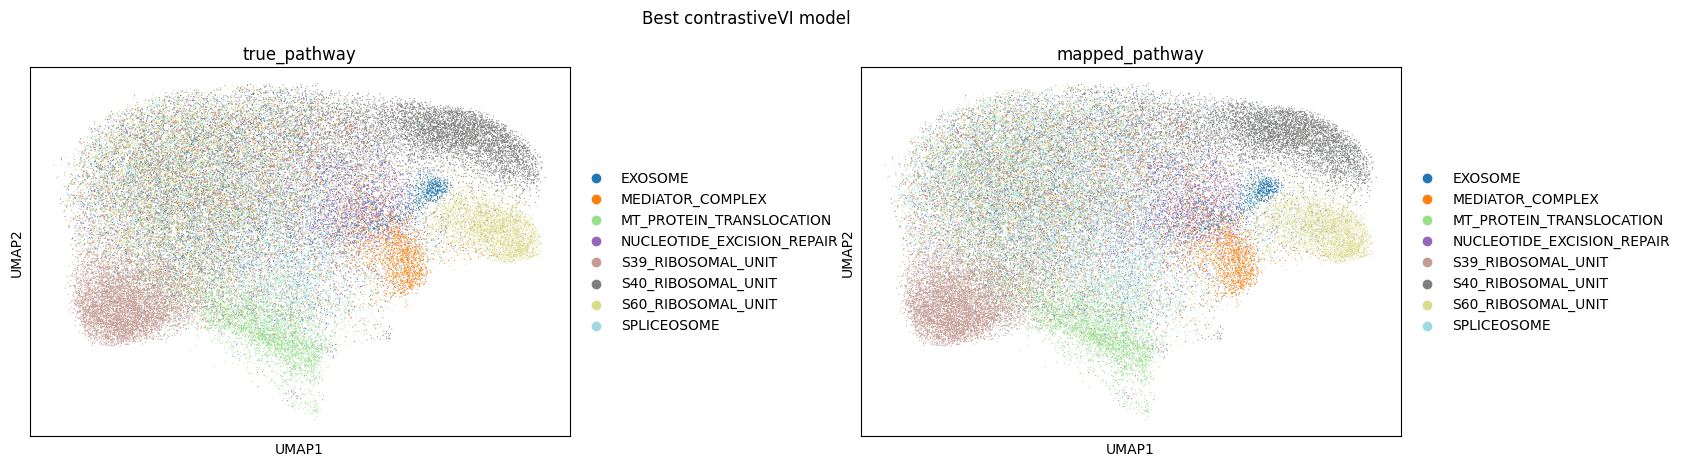


Generating figure for best scgen model


/var/tmp/ipykernel_3799799/4013088432.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/scgen_best_umap.svg


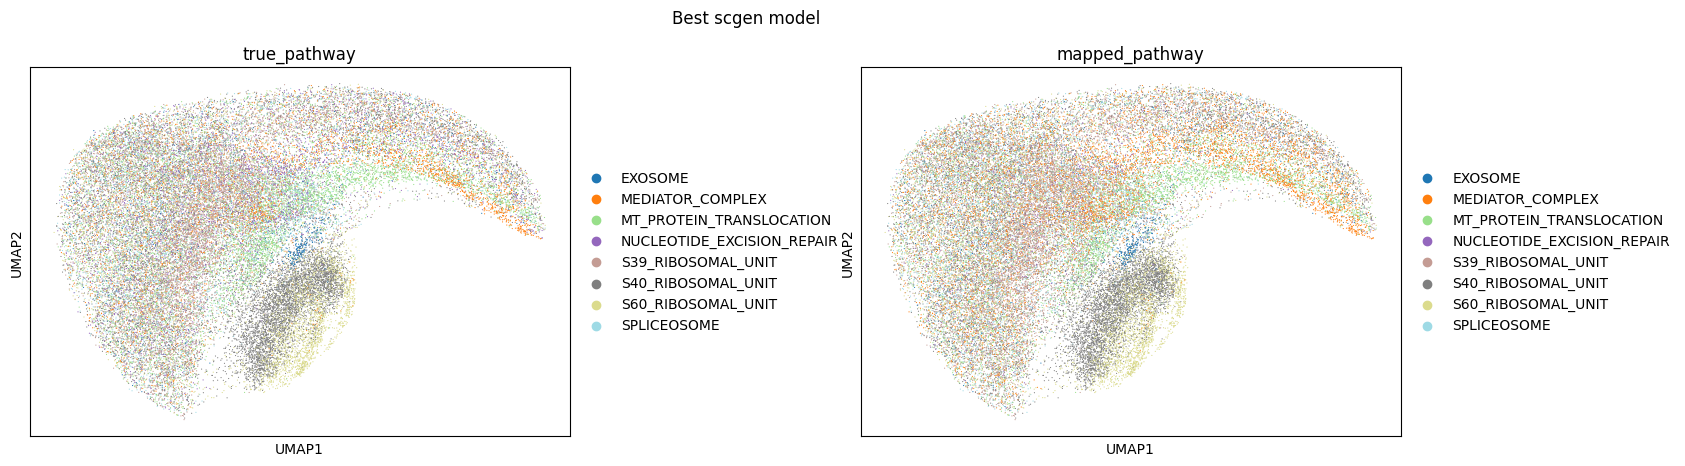

In [9]:
p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

for method_name, model in best_run_model.items():
    print(f"\n{'='*60}\nGenerating figure for best {method_name} model\n{'='*60}")

    # Re-eval the best model for this method
    slk.tl.eval(model, data, obsm_key='z', uns_key='results', device=DEVICE)

    # UMAP on non-NTC cells
    sub = data[data.obs[p_key] != NTC].copy()
    sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
    sc.tl.umap(sub)

    # Cluster z_corr on pathway genes
    z_corr  = np.asarray(data.uns['results']['z_corr'])
    z_perts = np.asarray(data.uns['results']['z_perts'])

    pert_to_idx = {name: i for i, name in enumerate(z_perts)}
    valid_genes = [g for g in all_genes_filtered if g in pert_to_idx]
    gene_ids    = [pert_to_idx[g] for g in valid_genes]

    cov_subset = z_corr[np.ix_(gene_ids, gene_ids)]
    cov_subset = np.clip(cov_subset, -1.0, 1.0)
    cov_subset = 0.5 * (cov_subset + cov_subset.T)
    np.fill_diagonal(cov_subset, 1.0)

    groups = slk.tl.cluster_rho(data, t=N_CLUSTERS, rho_corr=cov_subset, criterion='maxclust', show=False)

    # Hungarian alignment of cluster → pathway labels
    clusters_df = pd.DataFrame({'gene': valid_genes, 'cluster': groups})
    pw_df = pathway_df_indexed.loc[pathway_df_indexed.index.isin(valid_genes)].reset_index()
    if 'gene' not in pw_df.columns:
        pw_df = pw_df.rename(columns={pathway_df_indexed.index.name or 'index': 'gene'})

    df_align  = pd.merge(clusters_df, pw_df, on='gene', how='inner')
    y_true    = df_align['pathway'].astype(str).values
    y_pred    = df_align['cluster'].astype(str).values
    true_lbl  = np.unique(y_true)
    pred_lbl  = np.unique(y_pred)

    C_mat = (
        pd.crosstab(df_align['pathway'].astype(str), df_align['cluster'].astype(str))
        .reindex(index=true_lbl, columns=pred_lbl, fill_value=0)
    )
    row_ind, col_ind = linear_sum_assignment(C_mat.values.max() - C_mat.values)
    mapping = {pred_lbl[j]: true_lbl[i] for i, j in zip(row_ind, col_ind)}
    df_align['mapped_pathway'] = [mapping.get(str(cl)) for cl in y_pred]

    # Subset z_sub to clustered genes and attach pathway labels
    clustered_genes = df_align['gene'].unique()
    z_sub = sub[sub.obs[p_key].isin(clustered_genes)].copy()

    gene_to_true   = dict(zip(df_align['gene'], df_align['pathway']))
    gene_to_mapped = dict(zip(df_align['gene'], df_align['mapped_pathway']))
    z_sub.obs['true_pathway']   = z_sub.obs[p_key].map(gene_to_true)
    z_sub.obs['mapped_pathway'] = z_sub.obs[p_key].map(gene_to_mapped)
    z_sub = z_sub[z_sub.obs['mapped_pathway'].notna()].copy()

    # Shared categorical palette across both columns
    all_cats  = pd.Index(np.unique(
        list(z_sub.obs['true_pathway'].dropna().unique()) +
        list(z_sub.obs['mapped_pathway'].dropna().unique())
    ).astype(str))
    cat_dtype = pd.api.types.CategoricalDtype(categories=all_cats, ordered=False)
    z_sub.obs['true_pathway']   = z_sub.obs['true_pathway'].astype('string').astype(cat_dtype)
    z_sub.obs['mapped_pathway'] = z_sub.obs['mapped_pathway'].astype('string').astype(cat_dtype)

    cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))
    shared_palette = {cat: to_hex(cmap_col(i)) for i, cat in enumerate(all_cats)}
    z_sub.uns['true_pathway_colors']   = [shared_palette[c] for c in z_sub.obs['true_pathway'].cat.categories]
    z_sub.uns['mapped_pathway_colors'] = [shared_palette[c] for c in z_sub.obs['mapped_pathway'].cat.categories]

    # Plot and save
    fig = sc.pl.umap(
        z_sub,
        color=['true_pathway', 'mapped_pathway'],
        wspace=0.4,
        show=False,
        return_fig=True,
    )
    fig.suptitle(f'Best {method_name} model', y=1.02, fontsize=12)
    save_path = f'{RESULTS_DIR}/figures/{method_name}_best_umap.svg'
    fig.savefig(save_path, bbox_inches='tight')
    print(f"  Saved → {save_path}")
    plt.show()